In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import shutil
import seaborn as sns
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.cm as cm
import re
import pingouin as pg
from scipy.stats import sem
from pathlib import Path

def find_project_root(start=None):
    p = Path(os.environ.get('MAZE_PROJECT_ROOT') or start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / '_DATA').is_dir() and (cand / 'Mazes').is_dir():
            return cand
    raise RuntimeError(
        f'Could not locate the project root (a folder holding _DATA/ and Mazes/) '
        f'from {p}. Set MAZE_PROJECT_ROOT to the repository root.')

project_path = str(find_project_root())
os.chdir(project_path)

home_path  = os.path.expanduser('~')
data_path  = os.path.join(project_path, '_DATA')
maze_dir   = os.path.join(project_path, 'Mazes')
figure_path = os.path.join(project_path, 'figures')
os.makedirs(figure_path, exist_ok=True)

print(project_path)
print(data_path)

/Users/minjaejo/Desktop/2025_Maze_Behavior
/Users/minjaejo/Desktop/2025_Maze_Behavior/_DATA


In [2]:
def get_diffusivity(d, data):
    # get angular and linear diffusivity
    ang_diff, sin_D, cos_D = angular_diffusivity(d, data)
    lin_diff = linear_diffusivity(d, data)
    
    return {
        'angular': {
            'diffusivity': ang_diff,
            'sin': sin_D,
            'cos': cos_D
        },
        'linear': {
            'diffusivity': lin_diff
        }
    }

## angular diffusivity
def angular_diffusivity(delta, data):
    ang_diff = []

    for i in range(len(data)-delta):
        [x1, y1] = int(data.iloc[i]['Location'].split()[0]), int(data.iloc[i]['Location'].split()[1])
        [x2, y2] = int(data.iloc[i+delta]['Location'].split()[0]), int(data.iloc[i+delta]['Location'].split()[1])
        
        y = np.arctan2(y2-y1, x2-x1)
        ang_diff.append(y)

    sin_D = np.round(np.mean(np.sin(ang_diff)), 5)
    cos_D = np.round(np.mean(np.cos(ang_diff)), 5)

    return ang_diff, sin_D, cos_D

## linear diffusivity
def linear_diffusivity(delta, data):
    diff = []
    for i in range(len(data)-delta):
        [x1, y1] = int(data.iloc[i]['Location'].split()[0]), int(data.iloc[i]['Location'].split()[1])
        [x2, y2] = int(data.iloc[i+delta]['Location'].split()[0]), int(data.iloc[i+delta]['Location'].split()[1])
        
        y = (x2-x1)**2 + (y2-y1)**2
        diff.append(y)
    return np.round(np.mean(diff), 5)

In [ ]:
exclude_subs = []

file_types = ['EgoEgo', 'AlloEgo', 'EgoAllo', 'AlloAllo']
stats_list = []
delta=3
collapsed_list = pd.DataFrame()

for i, file_type in enumerate(file_types):

    subject_dirs = [os.path.join(data_path, d) for d in os.listdir(data_path)
                    if os.path.isdir(os.path.join(data_path, d)) and d.startswith('Sub-')]
    subject_dirs = [d for d in subject_dirs if not any(sub in d for sub in exclude_subs)]

    frames = []
    for dir in subject_dirs:
        fp = os.path.join(dir, f"{os.path.basename(dir).lower()}_{file_type}.csv")
        if os.path.exists(fp):
            df = pd.read_csv(fp)
            subject_id = int(os.path.basename(dir).split('-')[1])
            df['subject_id'] = subject_id
            frames.append(df)

    all_data = pd.concat(frames, ignore_index=True)
    all_data = all_data.sort_values(by=['subject_id', 'Trial', 'Time'])
    all_data = all_data.reset_index(drop=True)
    
    data = all_data.groupby(['PhaseView', 'subject_id', 'Trial'])
    subject_results=[]

    for name, group in data:
        condition, sub, trial = name
        diffusivity = get_diffusivity(delta,group)
        
        if condition == 0:
            condition = 'EgoTrain'
        elif condition == 1:
            condition = 'AlloTrain'
        elif condition == 2:
            condition = 'EgoTest'
        elif condition == 3:
            condition = 'AlloTest'
            
        subject_results.append({
            'condition': condition,
            'subject_id': sub,
            'trial': trial,
            'diffusivity': diffusivity
        })
        
    # save subject_results to csv
    output_path = os.path.join(project_path, 'diffusivity')
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    output_file = os.path.join(output_path, f'diffusivity_{file_type}_window_{delta}.csv')
    with open(output_file, 'w', newline='') as csvfile:
        fieldnames = ['condition', 'subject_id', 'trial', 'angular_diffusivity', 'angular_sin', 'angular_cos', 'linear_diffusivity']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        
        writer.writeheader()
        for result in subject_results:
            writer.writerow({
                'condition': result['condition'],
                'subject_id': result['subject_id'],
                'trial': result['trial'],
                'angular_diffusivity': np.round(np.mean(result['diffusivity']['angular']['diffusivity']),5),
                'angular_sin': result['diffusivity']['angular']['sin'],
                'angular_cos': result['diffusivity']['angular']['cos'],
                'linear_diffusivity': result['diffusivity']['linear']['diffusivity']
            })

In [4]:
# read data
cmap = ["#377eb8", "#e41a1c", '#2ca02c', '#FA812F']  # EgoEgo, AlloEgo, EgoAllo, AlloAllo
path = os.path.join(project_path, 'diffusivity')
condition = ['EgoEgo', 'AlloEgo']
results = []
for i, c in enumerate(condition):
    data = pd.read_csv(os.path.join(path, f'diffusivity_{c}_window_{delta}.csv'))
    data['TrialMap']=data.groupby(['subject_id', 'condition']).cumcount()+1
    # 6fold + linear diffusivity for all subjects
    data['Trial6'] = ((data['TrialMap'] - 1) % 6) + 1
    data = data[['subject_id', 'condition', 'trial', 'TrialMap', 'Trial6', 'linear_diffusivity']]
    lin_diff_all = (
        data.groupby(['subject_id', 'condition', 'Trial6'])['linear_diffusivity']
            .agg(lin_diff_avg='mean')
            .reset_index()
    )

    # Mean & sem
    lin_diff_stats = lin_diff_all.groupby(['condition', 'Trial6']).agg(
        lin_diff_avg=('lin_diff_avg', 'mean'),
        lin_diff_sem=('lin_diff_avg', lambda x: sem(x, nan_policy='omit'))
    ).reset_index()
    
    results.append(lin_diff_stats)
    
results = pd.DataFrame(pd.concat(results, ignore_index=True))

In [5]:
from scipy.stats import f as f_dist

path = os.path.join(project_path, 'diffusivity')
delta = 3

def load_subject_test(file_type, test_condition):
    data = pd.read_csv(os.path.join(path, f'diffusivity_{file_type}_window_{delta}.csv'))
    data['TrialMap'] = data.groupby(['subject_id', 'condition']).cumcount() + 1
    data['Trial6'] = ((data['TrialMap'] - 1) % 6) + 1
    test = data[data['condition'] == test_condition].copy()
    return (test.groupby(['subject_id', 'Trial6'])['linear_diffusivity']
                .mean().reset_index().rename(columns={'linear_diffusivity': 'lin_diff'}))


blocks = [('EgoEgo',   'EgoTest',  'Ego',  'Ego'),    # Player -> Player : Match
          ('AlloEgo',  'EgoTest',  'Allo', 'Ego'),    # Map    -> Player : Mismatch
          ('AlloAllo', 'AlloTest', 'Allo', 'Allo'),   # Map    -> Map    : Match
          ('EgoAllo',  'AlloTest', 'Ego',  'Allo')]   # Player -> Map    : Mismatch

frames = []
for ft, tc, learn, retr in blocks:
    d = load_subject_test(ft, tc)
    d['learning'], d['retrieval'], d['file_type'] = learn, retr, ft
    frames.append(d)
test_all = pd.concat(frames, ignore_index=True)
test_all['congruency'] = np.where(test_all['learning'] == test_all['retrieval'],
                                  'Match', 'Mismatch')

print('design check (subjects per cell):')
print(test_all.groupby(['retrieval', 'congruency'])['subject_id'].nunique().to_string())
print('cells per subject:', test_all.groupby('subject_id').size().unique(),
      '| N =', test_all['subject_id'].nunique())


def gg_epsilon(mat):
    k = mat.shape[1]
    S = np.cov(mat, rowvar=False, ddof=1)
    sbar, dbar, rowm = S.mean(), np.mean(np.diag(S)), S.mean(axis=1)
    num = k**2 * (dbar - sbar)**2
    den = (k - 1) * (np.sum(S**2) - 2*k*np.sum(rowm**2) + k**2 * sbar**2)
    return num / den


def mixed_anova_2within_1between(data, dv, subject, between, w1, w2):
    d = data.copy()
    grand = d[dv].mean()
    a, b, c = d[between].nunique(), d[w1].nunique(), d[w2].nunique()
    n_per_group = d.groupby(between)[subject].nunique().unique()
    assert len(n_per_group) == 1, 'groups are unbalanced'
    n = n_per_group[0]
    assert (d.groupby(subject).size() == b * c).all(), 'missing cells'

    sub_grp = d[[subject, between]].drop_duplicates().set_index(subject)[between]
    cm = lambda keys: d.groupby(keys)[dv].mean()
    m_A, m_B, m_C = cm([between]), cm([w1]), cm([w2])
    m_AB, m_AC, m_BC = cm([between, w1]), cm([between, w2]), cm([w1, w2])
    m_ABC = cm([between, w1, w2])
    m_S, m_SB, m_SC, m_SBC = cm([subject]), cm([subject, w1]), cm([subject, w2]), cm([subject, w1, w2])
    A_, B_, C_ = m_A.index, m_B.index, m_C.index

    SS_A = b*c*n*((m_A - grand)**2).sum()
    SS_B = a*c*n*((m_B - grand)**2).sum()
    SS_C = a*b*n*((m_C - grand)**2).sum()
    SS_AB = c*n*sum((m_AB[i, j] - m_A[i] - m_B[j] + grand)**2 for i in A_ for j in B_)
    SS_AC = b*n*sum((m_AC[i, k] - m_A[i] - m_C[k] + grand)**2 for i in A_ for k in C_)
    SS_BC = a*n*sum((m_BC[j, k] - m_B[j] - m_C[k] + grand)**2 for j in B_ for k in C_)
    SS_ABC = n*sum((m_ABC[i, j, k] - m_AB[i, j] - m_AC[i, k] - m_BC[j, k]
                    + m_A[i] + m_B[j] + m_C[k] - grand)**2 for i in A_ for j in B_ for k in C_)
    SS_SwA = b*c*sum((m_S[s] - m_A[sub_grp[s]])**2 for s in m_S.index)
    SS_BSwA = c*sum((m_SB[s, j] - m_S[s] - m_AB[sub_grp[s], j] + m_A[sub_grp[s]])**2
                    for s in m_S.index for j in B_)
    SS_CSwA = b*sum((m_SC[s, k] - m_S[s] - m_AC[sub_grp[s], k] + m_A[sub_grp[s]])**2
                    for s in m_S.index for k in C_)
    SS_BCSwA = sum((m_SBC[s, j, k] - m_SB[s, j] - m_SC[s, k] - m_ABC[sub_grp[s], j, k]
                    + m_S[s] + m_AB[sub_grp[s], j] + m_AC[sub_grp[s], k] - m_A[sub_grp[s]])**2
                   for s in m_S.index for j in B_ for k in C_)

    df_A, df_SwA, df_B, df_C = a-1, a*(n-1), b-1, c-1
    dfs = dict(AB=df_A*df_B, AC=df_A*df_C, BC=df_B*df_C, ABC=df_A*df_B*df_C,
               BSwA=df_B*df_SwA, CSwA=df_C*df_SwA, BCSwA=df_B*df_C*df_SwA)

    def centered(values_df):
        return values_df.groupby(level=between).transform(lambda x: x - x.mean()).values
    w_C = (d.groupby([subject, between, w2])[dv].mean().unstack(w2)
             .reset_index().set_index([subject, between]))
    eps_C = gg_epsilon(centered(w_C))
    lv = list(B_)
    piv = d.groupby([subject, between, w1, w2])[dv].mean().unstack(w1)
    diff = (piv[lv[0]] - piv[lv[1]]).unstack(w2)
    diff.index = pd.MultiIndex.from_tuples(diff.index, names=[subject, between])
    eps_BC = gg_epsilon(centered(diff)) 

    rows = [(between,                    SS_A,   df_A,      SS_SwA,   df_SwA,     np.nan),
            (w1,                         SS_B,   df_B,      SS_BSwA,  dfs['BSwA'], 1.0),
            (w2,                         SS_C,   df_C,      SS_CSwA,  dfs['CSwA'], eps_C),
            (f'{between} * {w1}',        SS_AB,  dfs['AB'], SS_BSwA,  dfs['BSwA'], 1.0),
            (f'{between} * {w2}',        SS_AC,  dfs['AC'], SS_CSwA,  dfs['CSwA'], eps_C),
            (f'{w1} * {w2}',             SS_BC,  dfs['BC'], SS_BCSwA, dfs['BCSwA'], eps_BC),
            (f'{between} * {w1} * {w2}', SS_ABC, dfs['ABC'],SS_BCSwA, dfs['BCSwA'], eps_BC)]

    out = []
    for name, ss, df1, sse, df2, eps in rows:
        F = (ss/df1) / (sse/df2)
        p = f_dist.sf(F, df1, df2)
        p_gg = f_dist.sf(F, eps*df1, eps*df2) if np.isfinite(eps) and eps < 1 else np.nan
        out.append(dict(Source=name, SS=ss, df1=df1, df2=df2, MS=ss/df1, MSE=sse/df2,
                        F=F, p_unc=p, eps_GG=eps, p_GG=p_gg, np2=ss/(ss+sse)))
    aov = pd.DataFrame(out)
    ss_check = SS_A + SS_SwA + SS_B + SS_AB + SS_BSwA + SS_C + SS_AC + SS_CSwA + SS_BC + SS_ABC + SS_BCSwA
    assert np.isclose(ss_check, ((d[dv] - grand)**2).sum()), 'SS decomposition failed'
    return aov


aov3 = mixed_anova_2within_1between(test_all, dv='lin_diff', subject='subject_id',
                                    between='retrieval', w1='congruency', w2='Trial6')
print('\n=== 2 (Congruency) x 2 (Retrieval) x 6 (Trial) mixed ANOVA — linear diffusivity ===')
print(aov3.round(4).to_string(index=False))

# cell means +/- SEM (subject-level, averaged over trials)
cell = (test_all.groupby(['subject_id', 'retrieval', 'congruency'], as_index=False)['lin_diff'].mean())
print('\ncell means (averaged over trials):')
print(cell.groupby(['retrieval', 'congruency'])['lin_diff']
          .agg(M='mean', SEM=lambda x: sem(x, nan_policy='omit'), n='count').round(4).to_string())

design check (subjects per cell):
retrieval  congruency
Allo       Match         20
           Mismatch      20
Ego        Match         20
           Mismatch      20
cells per subject: [12] | N = 40

=== 2 (Congruency) x 2 (Retrieval) x 6 (Trial) mixed ANOVA — linear diffusivity ===
                         Source       SS  df1  df2       MS    MSE        F  p_unc  eps_GG   p_GG    np2
                      retrieval 232.5273    1   38 232.5273 0.8057 288.5961 0.0000     NaN    NaN 0.8836
                     congruency   3.0173    1   38   3.0173 0.2507  12.0342 0.0013  1.0000    NaN 0.2405
                         Trial6   6.3988    5  190   1.2798 0.0432  29.6431 0.0000  0.8514 0.0000 0.4382
         retrieval * congruency   0.5306    1   38   0.5306 0.2507   2.1163 0.1539  1.0000    NaN 0.0528
             retrieval * Trial6   0.0475    5  190   0.0095 0.0432   0.2200 0.9536  0.8514 0.9351 0.0058
            congruency * Trial6   0.4437    5  190   0.0887 0.0426   2.0816 0.0694  

In [6]:
row = aov3.query("Source == 'Trial6'").iloc[0]
eps, F, df1, df2 = row['eps_GG'], row['F'], row['df1'], row['df2']
print(f"Main effect of Trial: F({df1:.0f}, {df2:.0f}) = {F:.2f}, p = {row['p_unc']:.2e}, "
      f"partial eta^2 = {row['np2']:.3f}")
print(f"Greenhouse-Geisser: eps = {eps:.3f}, F({eps*df1:.2f}, {eps*df2:.2f}) = {F:.2f}, "
      f"p = {row['p_GG']:.2e}")

subj_trial = test_all.groupby(['subject_id', 'Trial6'], as_index=False)['lin_diff'].mean()
trial_desc = subj_trial.groupby('Trial6')['lin_diff'].agg(
    mean='mean', sd='std', sem=lambda x: sem(x, nan_policy='omit')).reset_index()
print('\nTrial marginal means (N = %d):' % subj_trial['subject_id'].nunique())
print(trial_desc.round(3).to_string(index=False))

lin_w = np.polynomial.polynomial.polyvander(np.arange(1, 7), 1)[:, 1]
lin_w = (lin_w - lin_w.mean())
wide_t = subj_trial.pivot(index='subject_id', columns='Trial6', values='lin_diff')
slopes = wide_t.values @ lin_w / (lin_w**2).sum()
print('\nLinear trend across trials:')
print(pg.ttest(slopes, 0).round(4).to_string(index=False))
print(f'mean slope = {slopes.mean():.4f} per trial')

ph = pg.pairwise_tests(dv='lin_diff', within='Trial6', subject='subject_id',
                       data=subj_trial, padjust='holm')
print('\nPairwise trial comparisons (Holm):')
print(ph[['A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'hedges']].round(4).to_string(index=False))

Main effect of Trial: F(5, 190) = 29.64, p = 3.40e-22, partial eta^2 = 0.438
Greenhouse-Geisser: eps = 0.851, F(4.26, 161.76) = 29.64, p = 3.02e-19

Trial marginal means (N = 40):
 Trial6  mean    sd   sem
      1 2.394 0.757 0.120
      2 2.532 0.769 0.122
      3 2.604 0.775 0.123
      4 2.682 0.753 0.119
      5 2.723 0.754 0.119
      6 2.707 0.760 0.120

Linear trend across trials:
     T  dof alternative  p-val        CI95%  cohen-d      BF10  power
9.9658   39   two-sided    0.0 [0.05, 0.08]   1.5757 3.068e+09    1.0
mean slope = 0.0633 per trial

Pairwise trial comparisons (Holm):
A B       T  dof  p-unc  p-corr  hedges
1 2 -3.6943 39.0 0.0007  0.0047 -0.1794
1 3 -5.4684 39.0 0.0000  0.0000 -0.2718
1 4 -8.5172 39.0 0.0000  0.0000 -0.3775
1 5 -9.0748 39.0 0.0000  0.0000 -0.4306
1 6 -8.2572 39.0 0.0000  0.0000 -0.4091
2 3 -2.0208 39.0 0.0502  0.2008 -0.0924
2 4 -5.1775 39.0 0.0000  0.0001 -0.1946
2 5 -6.5889 39.0 0.0000  0.0000 -0.2474
2 6 -4.7850 39.0 0.0000  0.0002 -0.2267
3 4

In [7]:
from scipy.stats import t as t_dist

w_all = cell.pivot_table(index=['subject_id', 'retrieval'], columns='congruency', values='lin_diff')
d_all = w_all['Match'] - w_all['Mismatch']
tt = pg.ttest(w_all['Match'], w_all['Mismatch'], paired=True)
ci = t_dist.ppf(0.975, len(d_all)-1) * sem(d_all)
r = aov3.set_index('Source').loc['congruency']
print(f"Congruency main effect: F({r.df1:.0f}, {r.df2:.0f}) = {r.F:.2f}, p = {r.p_unc:.4f}, "
      f"partial eta^2 = {r.np2:.3f}")
print(f"  Match - Mismatch = {d_all.mean():+.4f}  95% CI [{d_all.mean()-ci:.4f}, {d_all.mean()+ci:.4f}], "
      f"t({tt['dof'].iloc[0]:.0f}) = {tt['T'].iloc[0]:.2f}, d_z = {tt['T'].iloc[0]/np.sqrt(len(d_all)):.2f}")
rxc = aov3.set_index('Source').loc['retrieval * congruency']
print('  by group:', {g: f'{v:+.3f}' for g, v in d_all.groupby(level='retrieval').mean().items()},
      f"| congruency x retrieval: F({rxc.df1:.0f}, {rxc.df2:.0f}) = {rxc.F:.2f}, p = {rxc.p_unc:.3f}")

w_t = test_all.pivot_table(index=['subject_id', 'retrieval', 'Trial6'],
                           columns='congruency', values='lin_diff')
D = (w_t['Match'] - w_t['Mismatch']).unstack('Trial6')
rows = []
for t in D.columns:
    v = D[t]
    tt = pg.ttest(v, 0)
    ci = t_dist.ppf(0.975, len(v)-1) * sem(v)
    rows.append(dict(Trial=t, diff=v.mean(), CI_lo=v.mean()-ci, CI_hi=v.mean()+ci,
                     t=tt['T'].iloc[0], p=tt['p-val'].iloc[0], BF10=float(tt['BF10'].iloc[0]),
                     n_pos=int((v > 0).sum())))
per_trial = pd.DataFrame(rows)
per_trial['p_holm'] = pg.multicomp(per_trial['p'].values, method='holm')[1]
print('\nMatch - Mismatch per trial (N = 40):')
print(per_trial.round(4).to_string(index=False))

r = aov3.set_index('Source').loc['congruency * Trial6']
print(f"\nCongruency x Trial: F({r.df1:.0f}, {r.df2:.0f}) = {r.F:.2f}, p = {r.p_unc:.4f}, "
      f"GG eps = {r.eps_GG:.3f}, p_GG = {r.p_GG:.4f}, partial eta^2 = {r.np2:.3f}")
early, mid, last = D[[1, 2]].mean(axis=1), D[[3, 4, 5]].mean(axis=1), D[6]
for nm, v in [('early (T1-2)', early), ('mid (T3-5)', mid), ('last (T6)', last)]:
    tt = pg.ttest(v, 0)
    print(f'  {nm:14s} {v.mean():+.3f}  t(39) = {tt["T"].iloc[0]:+.2f}, p = {tt["p-val"].iloc[0]:.4f}')
tt = pg.ttest(early, mid, paired=True)
print(f'  early vs mid   {(early-mid).mean():+.3f}  t(39) = {tt["T"].iloc[0]:+.2f}, p = {tt["p-val"].iloc[0]:.4f}')

Congruency main effect: F(1, 38) = 12.03, p = 0.0013, partial eta^2 = 0.241
  Match - Mismatch = +0.1586  95% CI [0.0648, 0.2523], t(39) = 3.42, d_z = 0.54
  by group: {'Allo': '+0.225', 'Ego': '+0.092'} | congruency x retrieval: F(1, 38) = 2.12, p = 0.154

Match - Mismatch per trial (N = 40):
 Trial   diff   CI_lo  CI_hi      t      p   BF10  n_pos  p_holm
     1 0.2001  0.0934 0.3069 3.7912 0.0005 55.893     30  0.0030
     2 0.2459  0.1149 0.3768 3.7977 0.0005 56.859     30  0.0030
     3 0.1203 -0.0162 0.2568 1.7825 0.0824  0.721     24  0.1857
     4 0.1108 -0.0058 0.2274 1.9223 0.0619  0.902     25  0.1857
     5 0.0732 -0.0636 0.2101 1.0830 0.2855  0.294     25  0.2855
     6 0.2011  0.0731 0.3291 3.1778 0.0029 11.909     30  0.0116

Congruency x Trial: F(5, 190) = 2.08, p = 0.0694, GG eps = 0.819, p_GG = 0.0842, partial eta^2 = 0.052
  early (T1-2)   +0.223  t(39) = +4.42, p = 0.0001
  mid (T3-5)     +0.101  t(39) = +1.87, p = 0.0692
  last (T6)      +0.201  t(39) = +3.18, p = 

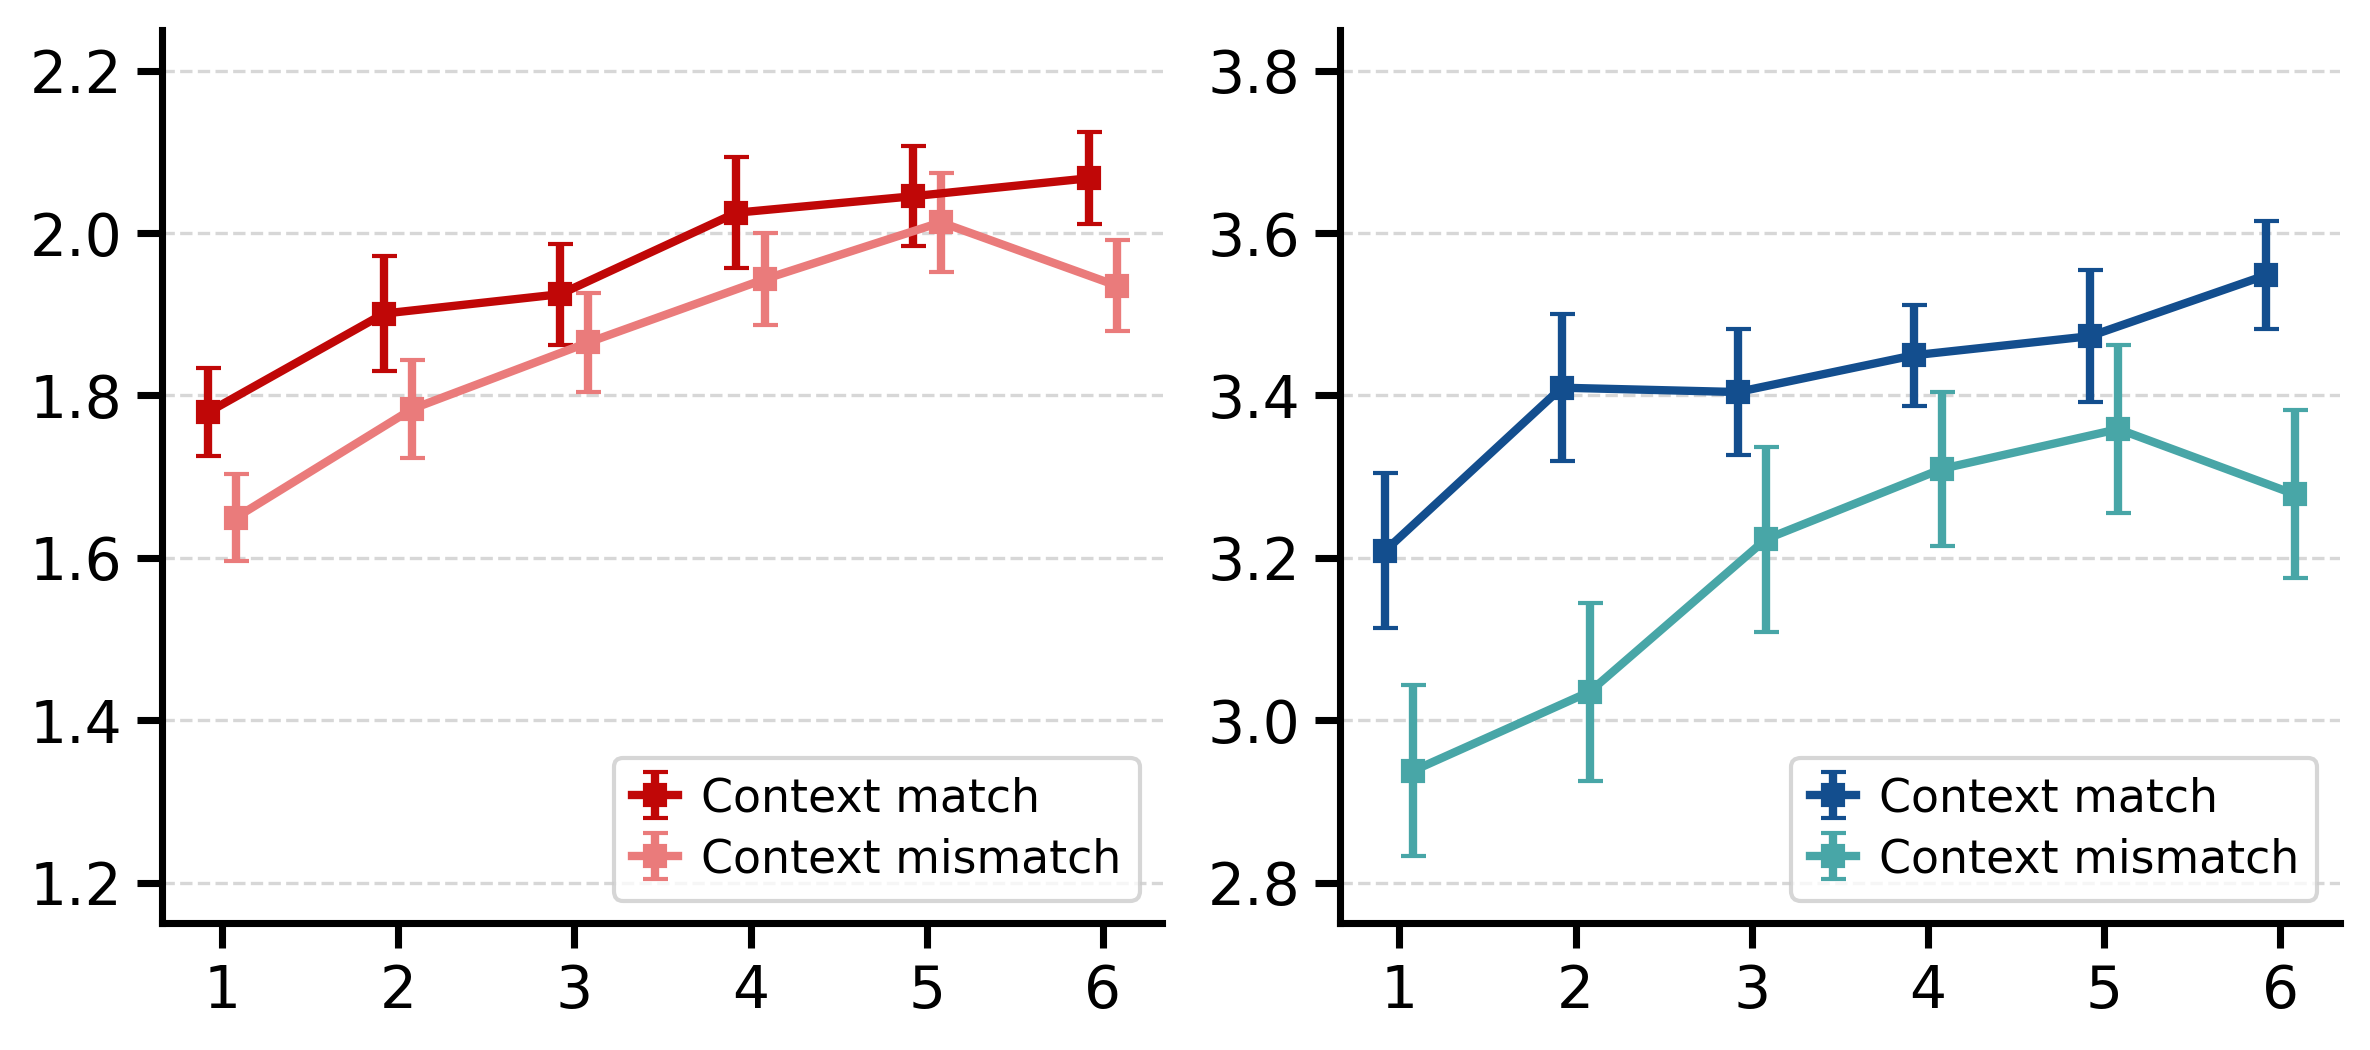

In [8]:
colors = ["#C00707", "#EA7B7B", '#134E8E', '#48A6A7']   # G1 match, G1 mismatch, G2 match, G2 mismatch
labels = {'Match': 'Context match', 'Mismatch': 'Context mismatch'}

panel  = {'Ego':  dict(c=(colors[0], colors[1])),
          'Allo': dict(c=(colors[2], colors[3]))}
YTICK_STEP = 0.2 
MARGIN     = 0.05 
LEG_ROOM   = 0.25 
AXIS_LW    = 1.7
LINE_LW    = 2.0 
TICK_FS    = 14 
LEG_FS     = 11

curves, extent = {}, {}
for retr in ['Ego', 'Allo']:
    g = test_all[test_all['retrieval'] == retr]
    cs = {cond: (g[g.congruency == cond].groupby('Trial6')['lin_diff']
                 .agg(m='mean', se=lambda x: sem(x, nan_policy='omit')).reset_index())
          for cond in ['Match', 'Mismatch']}
    curves[retr] = cs
    extent[retr] = (min((c['m'] - c['se']).min() for c in cs.values()),
                    max((c['m'] + c['se']).max() for c in cs.values()))

need = max(hi - lo for lo, hi in extent.values()) + LEG_ROOM
n_ticks = int(np.ceil((need - 2 * MARGIN) / YTICK_STEP)) + 1

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), dpi=300)
for ax, retr in zip(axes, ['Ego', 'Allo']):
    for i, cond in enumerate(['Match', 'Mismatch']):
        s = curves[retr][cond]
        ax.errorbar(s['Trial6'] + (i * 0.16 - 0.08), s['m'], yerr=s['se'],
                    fmt='-s', color=panel[retr]['c'][i], label=labels[cond],
                    capsize=3, lw=LINE_LW, markersize=5)
    lo, hi = extent[retr]

    top = np.ceil((hi + MARGIN) / YTICK_STEP) * YTICK_STEP
    ticks = np.round(top - YTICK_STEP * np.arange(n_ticks)[::-1], 10)
    ax.set_yticks(ticks)
    ax.set_ylim(ticks[0] - MARGIN, ticks[-1] + MARGIN)
    assert ticks[0] - MARGIN <= lo and hi <= ticks[-1] + MARGIN, 'data outside the axis'
    ax.set_xticks(range(1, 7)) 
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(frameon=True, fontsize=LEG_FS, loc='lower right',
              markerscale=1.0, handlelength=1.0, handletextpad=0.5,
              borderpad=0.4, labelspacing=0.35, borderaxespad=0.5)
    sns.despine(ax=ax)
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(AXIS_LW)
    ax.tick_params(width=AXIS_LW, length=6, labelsize=TICK_FS)

plt.tight_layout()
for ext in ('png', 'pdf', 'svg'):
    plt.savefig(os.path.join(project_path, f'figures/BEH_04_Diffusivity_congruency.{ext}'),
                bbox_inches='tight')
plt.show()